<a href="https://colab.research.google.com/github/mohgeb/GlycemicPlus/blob/main/02_build_training_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path(
    "/content/drive/MyDrive/GlycemicSentinel"
)

DATA_DIR = PROJECT / "processed"

print("Project:", PROJECT)
print("Training data:", DATA_DIR)

Mounted at /content/drive
Project: /content/drive/MyDrive/GlycemicSentinel
Training data: /content/drive/MyDrive/GlycemicSentinel/processed


In [4]:
h5_files = sorted(DATA_DIR.glob("*.h5"))

print("H5 files found:", len(h5_files))

for path in h5_files:

    with h5py.File(path, "r") as h5:

        print(
            f"{path.stem:6s}",
            "PPG:", h5["ppg"].shape,
            "Labels:", h5["label"].shape
        )

H5 files found: 10
c1s01  PPG: (2124, 19200) Labels: (2124,)
c1s02  PPG: (2592, 19200) Labels: (2592,)
c1s03  PPG: (2550, 19200) Labels: (2550,)
c1s04  PPG: (2145, 19200) Labels: (2145,)
c1s05  PPG: (2745, 19200) Labels: (2745,)
c2s01  PPG: (2947, 19200) Labels: (2947,)
c2s02  PPG: (2098, 19200) Labels: (2098,)
c2s03  PPG: (2202, 19200) Labels: (2202,)
c2s04  PPG: (3139, 19200) Labels: (3139,)
c2s05  PPG: (3058, 19200) Labels: (3058,)


In [7]:
records = []

for path in h5_files:

    subject = path.stem

    with h5py.File(path, "r") as h5:

        labels = h5["label"][:]
        glucose = h5["glucose"][:]
        timestamps = h5["timestamp_ns"][:]

        for i in range(len(labels)):

            records.append({
                "subject": subject,
                "file": str(path),
                "row": i,
                "label": int(labels[i]),
                "glucose": float(glucose[i]),
                "timestamp_ns": int(timestamps[i])
            })

index_df = pd.DataFrame(records)

print("Total training windows:", len(index_df))

display(index_df.head())


Total training windows: 25600


,subject,file,row,label,glucose,timestamp_ns
0,c1s01,/content/drive/MyDrive/GlycemicSentinel/proces...,0,1,128.0,1654695828000000000
1,c1s01,/content/drive/MyDrive/GlycemicSentinel/proces...,1,1,135.0,1654696128000000000
2,c1s01,/content/drive/MyDrive/GlycemicSentinel/proces...,2,1,140.0,1654696727000000000
3,c1s01,/content/drive/MyDrive/GlycemicSentinel/proces...,3,1,137.0,1654697027000000000
4,c1s01,/content/drive/MyDrive/GlycemicSentinel/proces...,4,1,134.0,1654697327000000000


In [8]:
label_names = {
    0: "Hypoglycemia",
    1: "In Range",
    2: "Hyperglycemia"
}

index_df["class_name"] = (
    index_df["label"].map(label_names)
)

print("Overall class distribution:")

class_counts = (
    index_df["class_name"]
    .value_counts()
)

display(class_counts)

print("\nPercentages:")

display(
    (
        index_df["class_name"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

Overall class distribution:


,count
class_name,
In Range,21439
Hyperglycemia,3267
Hypoglycemia,894



Percentages:


,proportion
class_name,
In Range,83.75
Hyperglycemia,12.76
Hypoglycemia,3.49


In [9]:
subject_distribution = pd.crosstab(
    index_df["subject"],
    index_df["class_name"]
)

display(subject_distribution)

class_name,Hyperglycemia,Hypoglycemia,In Range
subject,,,
c1s01,134,115,1875
c1s02,704,7,1881
c1s03,571,86,1893
c1s04,559,3,1583
c1s05,23,108,2614
c2s01,385,109,2453
c2s02,88,117,1893
c2s03,274,43,1885
c2s04,416,104,2619


In [10]:
TEST_SUBJECT = "c2s05"

train_df = index_df[
    index_df["subject"] != TEST_SUBJECT
].reset_index(drop=True)

test_df = index_df[
    index_df["subject"] == TEST_SUBJECT
].reset_index(drop=True)

print("TRAIN")
print("Subjects:", sorted(train_df["subject"].unique()))
print("Windows:", len(train_df))

print("\nTEST")
print("Subjects:", sorted(test_df["subject"].unique()))
print("Windows:", len(test_df))

print("\nTrain classes:")
display(train_df["class_name"].value_counts())

print("\nTest classes:")
display(test_df["class_name"].value_counts())

TRAIN
Subjects: ['c1s01', 'c1s02', 'c1s03', 'c1s04', 'c1s05', 'c2s01', 'c2s02', 'c2s03', 'c2s04']
Windows: 22542

TEST
Subjects: ['c2s05']
Windows: 3058

Train classes:


,count
class_name,
In Range,18696
Hyperglycemia,3154
Hypoglycemia,692



Test classes:


,count
class_name,
In Range,2743
Hypoglycemia,202
Hyperglycemia,113


In [11]:
train_subjects = set(train_df["subject"])
test_subjects = set(test_df["subject"])

assert train_subjects.isdisjoint(test_subjects)

print("✓ No participant leakage.")

✓ No participant leakage.


In [19]:
import numpy as np

from scipy.signal import (
    butter,
    sosfiltfilt,
    find_peaks,
    welch
)

from scipy.stats import skew, kurtosis


FS = 64

# Band-pass appropriate for pulsatile PPG
SOS = butter(
    4,
    [0.5, 8.0],
    btype="bandpass",
    fs=FS,
    output="sos"
)


def extract_ppg_features(signal):

    x = np.asarray(signal, dtype=np.float64)

    # 1. Filter
    x = sosfiltfilt(SOS, x)

    # 2. Robust normalization
    median = np.median(x)
    mad = np.median(np.abs(x - median))

    if mad < 1e-8:
        mad = 1e-8

    x = (x - median) / (1.4826 * mad)

    features = {}

    # Basic morphology/statistics
    features["std"] = np.std(x)
    features["rms"] = np.sqrt(np.mean(x ** 2))
    features["iqr"] = np.percentile(x, 75) - np.percentile(x, 25)
    features["ptp"] = np.ptp(x)
    features["skew"] = skew(x)
    features["kurtosis"] = kurtosis(x)

    dx = np.diff(x)

    features["diff_std"] = np.std(dx)
    features["diff_abs_mean"] = np.mean(np.abs(dx))

    # Pulse peaks / timing
    peaks, properties = find_peaks(
        x,
        distance=int(0.30 * FS),
        prominence=0.5
    )

    features["num_peaks"] = len(peaks)

    if len(peaks) >= 3:

        ibi = np.diff(peaks) / FS

        # Keep physiologically plausible intervals
        ibi = ibi[
            (ibi >= 0.30) &
            (ibi <= 2.0)
        ]

        if len(ibi) >= 2:

            features["mean_ibi"] = np.mean(ibi)
            features["sdnn"] = np.std(ibi)
            features["rmssd"] = np.sqrt(
                np.mean(np.diff(ibi) ** 2)
            )

            features["estimated_hr"] = (
                60.0 / np.mean(ibi)
            )

        else:
            features["mean_ibi"] = np.nan
            features["sdnn"] = np.nan
            features["rmssd"] = np.nan
            features["estimated_hr"] = np.nan

    else:
        features["mean_ibi"] = np.nan
        features["sdnn"] = np.nan
        features["rmssd"] = np.nan
        features["estimated_hr"] = np.nan


    # Frequency-domain features
    frequencies, power = welch(
        x,
        fs=FS,
        nperseg=2048
    )

    total_mask = (
        (frequencies >= 0.5) &
        (frequencies <= 8.0)
    )

    total_power = np.trapezoid(
        power[total_mask],
        frequencies[total_mask]
    )

    def band_power(low, high):

        mask = (
            (frequencies >= low) &
            (frequencies < high)
        )

        bp = np.trapezoid(
            power[mask],
            frequencies[mask]
        )

        return bp / (total_power + 1e-12)

    features["power_0_5_1"] = band_power(0.5, 1.0)
    features["power_1_2"] = band_power(1.0, 2.0)
    features["power_2_4"] = band_power(2.0, 4.0)
    features["power_4_8"] = band_power(4.0, 8.0)

    pulse_mask = (
        (frequencies >= 0.5) &
        (frequencies <= 3.5)
    )

    pulse_f = frequencies[pulse_mask]
    pulse_p = power[pulse_mask]

    features["dominant_frequency"] = (
        pulse_f[np.argmax(pulse_p)]
    )

    return features

In [20]:
# Grab the first training observation
example = train_df.iloc[0]

with h5py.File(example["file"], "r") as h5:
    ppg = h5["ppg"][int(example["row"])]

features = extract_ppg_features(ppg)

pd.DataFrame(
    [features]
).T.rename(columns={0: "value"})

,value
std,3.673937
rms,3.674182
iqr,1.355473
ptp,56.572462
skew,-0.491860
kurtosis,9.771661
diff_std,0.596158
diff_abs_mean,0.312427
num_peaks,421.000000
mean_ibi,0.719543


In [21]:
from pathlib import Path
import h5py
import pandas as pd
import numpy as np
import time

FEATURE_DIR = PROJECT / "features"
FEATURE_DIR.mkdir(parents=True, exist_ok=True)

feature_files = []

for h5_path in h5_files:

    subject = h5_path.stem

    output_path = FEATURE_DIR / f"{subject}_ppg_features.csv"

    # Crash/restart protection
    if output_path.exists():
        print(f"{subject}: already completed — skipping.")
        feature_files.append(output_path)
        continue

    print("\n" + "=" * 60)
    print("EXTRACTING:", subject)
    print("=" * 60)

    rows = []

    start_time = time.time()

    with h5py.File(h5_path, "r") as h5:

        ppg_ds = h5["ppg"]
        glucose_ds = h5["glucose"]
        label_ds = h5["label"]
        timestamp_ds = h5["timestamp_ns"]

        total = len(label_ds)

        for i in range(total):

            signal = ppg_ds[i]

            try:
                features = extract_ppg_features(signal)

            except Exception as e:
                print(
                    f"\nWarning: {subject} row {i} failed:",
                    str(e)
                )
                continue

            features.update({
                "subject": subject,
                "row": i,
                "glucose": float(glucose_ds[i]),
                "label": int(label_ds[i]),
                "timestamp_ns": int(timestamp_ds[i])
            })

            rows.append(features)

            if (i + 1) % 250 == 0:
                elapsed = time.time() - start_time

                print(
                    f"\r{i+1}/{total} "
                    f"({(i+1)/total*100:.1f}%) "
                    f"| {elapsed/60:.1f} min",
                    end=""
                )

    subject_features = pd.DataFrame(rows)

    subject_features.to_csv(
        output_path,
        index=False
    )

    feature_files.append(output_path)

    print(
        f"\nSaved {len(subject_features)} rows → "
        f"{output_path.name}"
    )


EXTRACTING: c1s01
2000/2124 (94.2%) | 0.5 min
Saved 2124 rows → c1s01_ppg_features.csv

EXTRACTING: c1s02
2500/2592 (96.5%) | 0.5 min
Saved 2592 rows → c1s02_ppg_features.csv

EXTRACTING: c1s03
2500/2550 (98.0%) | 0.5 min
Saved 2550 rows → c1s03_ppg_features.csv

EXTRACTING: c1s04
2000/2145 (93.2%) | 0.4 min
Saved 2145 rows → c1s04_ppg_features.csv

EXTRACTING: c1s05
2500/2745 (91.1%) | 0.4 min
Saved 2745 rows → c1s05_ppg_features.csv

EXTRACTING: c2s01
2750/2947 (93.3%) | 0.5 min
Saved 2947 rows → c2s01_ppg_features.csv

EXTRACTING: c2s02
2000/2098 (95.3%) | 0.3 min
Saved 2098 rows → c2s02_ppg_features.csv

EXTRACTING: c2s03
2000/2202 (90.8%) | 0.4 min
Saved 2202 rows → c2s03_ppg_features.csv

EXTRACTING: c2s04
3000/3139 (95.6%) | 0.5 min
Saved 3139 rows → c2s04_ppg_features.csv

EXTRACTING: c2s05
3000/3058 (98.1%) | 0.5 min
Saved 3058 rows → c2s05_ppg_features.csv


In [22]:
feature_files = sorted(
    FEATURE_DIR.glob("*_ppg_features.csv")
)

feature_df = pd.concat(
    [pd.read_csv(f) for f in feature_files],
    ignore_index=True
)

print("Subjects:", feature_df["subject"].nunique())
print("Total feature rows:", len(feature_df))
print("Columns:", len(feature_df.columns))

display(feature_df.head())

Subjects: 10
Total feature rows: 25600
Columns: 23


,std,rms,iqr,ptp,skew,kurtosis,diff_std,diff_abs_mean,num_peaks,mean_ibi,...,power_0_5_1,power_1_2,power_2_4,power_4_8,dominant_frequency,subject,row,glucose,label,timestamp_ns
0,3.673937,3.674182,1.355473,56.572462,-0.491860,9.771661,0.596158,0.312427,421,0.719543,...,0.381812,0.404872,0.149951,0.025574,0.93750,c1s01,0,128.0,1,1654695828000000000
1,1.783247,1.783306,1.347651,21.327849,-0.269742,4.388167,0.304125,0.187797,408,0.724732,...,0.280663,0.485444,0.171969,0.026616,1.09375,c1s01,1,135.0,1,1654696128000000000
2,3.124286,3.124520,1.349844,55.089215,-1.162450,13.537554,0.549892,0.290202,450,0.647276,...,0.291827,0.434190,0.212777,0.028670,0.71875,c1s01,2,140.0,1,1654696727000000000
3,1.795799,1.795803,1.348946,33.329597,-0.005189,9.572604,0.376139,0.227918,494,0.613978,...,0.274044,0.437273,0.171349,0.072356,0.87500,c1s01,3,137.0,1,1654697027000000000
4,1.459353,1.459353,1.348582,17.865635,0.173923,3.678756,0.339529,0.238974,544,0.564589,...,0.270079,0.385067,0.206180,0.115748,0.81250,c1s01,4,134.0,1,1654697327000000000


In [23]:
print("Rows per subject:")
display(
    feature_df["subject"]
    .value_counts()
    .sort_index()
)

print("\nClass counts:")
display(
    feature_df["label"]
    .value_counts()
    .sort_index()
)

print("\nMissing feature values:")
display(
    feature_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

Rows per subject:


,count
subject,
c1s01,2124
c1s02,2592
c1s03,2550
c1s04,2145
c1s05,2745
c2s01,2947
c2s02,2098
c2s03,2202
c2s04,3139



Class counts:


,count
label,
0,894
1,21439
2,3267



Missing feature values:


,0
std,0
rms,0
iqr,0
ptp,0
skew,0
kurtosis,0
diff_std,0
diff_abs_mean,0
num_peaks,0
mean_ibi,0


In [24]:
MASTER_FEATURE_FILE = (
    FEATURE_DIR / "physiocgm_ppg_features.csv"
)

feature_df.to_csv(
    MASTER_FEATURE_FILE,
    index=False
)

print("Saved:")
print(MASTER_FEATURE_FILE)

Saved:
/content/drive/MyDrive/GlycemicSentinel/features/physiocgm_ppg_features.csv


In [25]:
import pandas as pd
from pathlib import Path

FEATURE_FILE = Path(
    "/content/drive/MyDrive/GlycemicSentinel/"
    "features/physiocgm_ppg_features.csv"
)

df = pd.read_csv(FEATURE_FILE)

print("Rows:", len(df))
print("Subjects:", df["subject"].nunique())
print("Columns:", len(df.columns))

display(df.head())

Rows: 25600
Subjects: 10
Columns: 23


,std,rms,iqr,ptp,skew,kurtosis,diff_std,diff_abs_mean,num_peaks,mean_ibi,...,power_0_5_1,power_1_2,power_2_4,power_4_8,dominant_frequency,subject,row,glucose,label,timestamp_ns
0,3.673937,3.674182,1.355473,56.572462,-0.491860,9.771661,0.596158,0.312427,421,0.719543,...,0.381812,0.404872,0.149951,0.025574,0.93750,c1s01,0,128.0,1,1654695828000000000
1,1.783247,1.783306,1.347651,21.327849,-0.269742,4.388167,0.304125,0.187797,408,0.724732,...,0.280663,0.485444,0.171969,0.026616,1.09375,c1s01,1,135.0,1,1654696128000000000
2,3.124286,3.124520,1.349844,55.089215,-1.162450,13.537554,0.549892,0.290202,450,0.647276,...,0.291827,0.434190,0.212777,0.028670,0.71875,c1s01,2,140.0,1,1654696727000000000
3,1.795799,1.795803,1.348946,33.329597,-0.005189,9.572604,0.376139,0.227918,494,0.613978,...,0.274044,0.437273,0.171349,0.072356,0.87500,c1s01,3,137.0,1,1654697027000000000
4,1.459353,1.459353,1.348582,17.865635,0.173923,3.678756,0.339529,0.238974,544,0.564589,...,0.270079,0.385067,0.206180,0.115748,0.81250,c1s01,4,134.0,1,1654697327000000000


In [26]:
NON_FEATURE_COLUMNS = [
    "subject",
    "row",
    "glucose",       # NEVER use this as input
    "label",
    "timestamp_ns"
]

feature_columns = [
    c for c in df.columns
    if c not in NON_FEATURE_COLUMNS
]

print("Model features:")
for feature in feature_columns:
    print("-", feature)

print("\nNumber of features:", len(feature_columns))

Model features:
- std
- rms
- iqr
- ptp
- skew
- kurtosis
- diff_std
- diff_abs_mean
- num_peaks
- mean_ibi
- sdnn
- rmssd
- estimated_hr
- power_0_5_1
- power_1_2
- power_2_4
- power_4_8
- dominant_frequency

Number of features: 18


In [27]:
TEST_SUBJECT = "c2s05"

train_df = df[
    df["subject"] != TEST_SUBJECT
].copy()

test_df = df[
    df["subject"] == TEST_SUBJECT
].copy()

X_train = train_df[feature_columns]
y_train = train_df["label"]

X_test = test_df[feature_columns]
y_test = test_df["label"]

print("Training subjects:")
print(sorted(train_df["subject"].unique()))

print("\nTest subjects:")
print(sorted(test_df["subject"].unique()))

print("\nTraining windows:", len(train_df))
print("Test windows:", len(test_df))

assert set(train_df["subject"]).isdisjoint(
    set(test_df["subject"])
)

print("\n✓ No participant leakage.")

Training subjects:
['c1s01', 'c1s02', 'c1s03', 'c1s04', 'c1s05', 'c2s01', 'c2s02', 'c2s03', 'c2s04']

Test subjects:
['c2s05']

Training windows: 22542
Test windows: 3058

✓ No participant leakage.


In [28]:
missing = (
    X_train
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing[missing > 0]
)

,0


In [29]:
!pip install -q xgboost

In [31]:
from xgboost import XGBClassifier

from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score
)

import numpy as np

In [32]:
imputer = SimpleImputer(
    strategy="median"
)

X_train_clean = imputer.fit_transform(X_train)

# IMPORTANT:
# fit only happened on TRAINING data.
X_test_clean = imputer.transform(X_test)

In [33]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print("Sample weight range:")
print(
    sample_weights.min(),
    "→",
    sample_weights.max()
)

Sample weight range:
0.4019041506204536 → 10.858381502890174


In [34]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,

    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_lambda=1.0,

    eval_metric="mlogloss",

    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_clean,
    y_train,
    sample_weight=sample_weights
)

print("✓ Model trained.")

✓ Model trained.


In [35]:
y_pred = model.predict(
    X_test_clean
)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Hypoglycemia",
            "In Range",
            "Hyperglycemia"
        ],
        digits=3,
        zero_division=0
    )
)

               precision    recall  f1-score   support

 Hypoglycemia      0.034     0.015     0.021       202
     In Range      0.901     0.692     0.783      2743
Hyperglycemia      0.047     0.363     0.084       113

     accuracy                          0.635      3058
    macro avg      0.328     0.356     0.296      3058
 weighted avg      0.812     0.635     0.706      3058



In [36]:
macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred
)

print("Macro F1:", round(macro_f1, 4))
print(
    "Balanced accuracy:",
    round(balanced_acc, 4)
)

Macro F1: 0.2957
Balanced accuracy: 0.3564


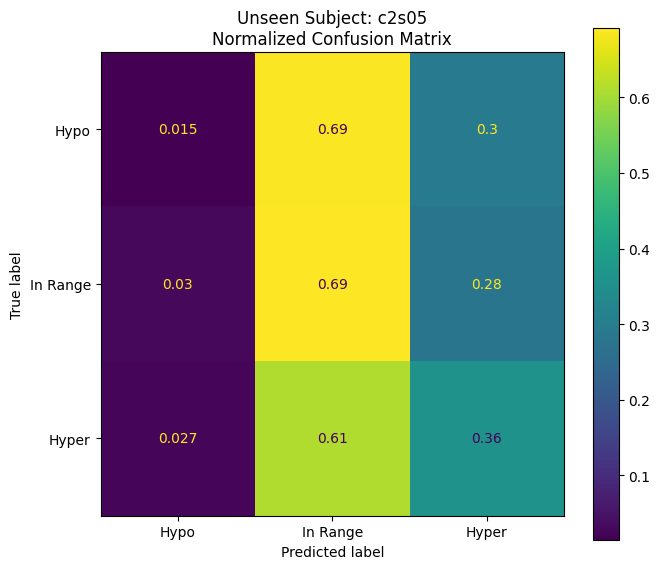

In [38]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "Hypo",
        "In Range",
        "Hyper"
    ],
    normalize="true",
    ax=ax
)

plt.title(
    f"Unseen Subject: {TEST_SUBJECT}\n"
    "Normalized Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [39]:
importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(importance_df)

,feature,importance
12,estimated_hr,0.079902
8,num_peaks,0.063150
1,rms,0.059799
7,diff_abs_mean,0.058143
9,mean_ibi,0.057709
14,power_1_2,0.056790
5,kurtosis,0.056176
3,ptp,0.055923
15,power_2_4,0.055154
16,power_4_8,0.053424


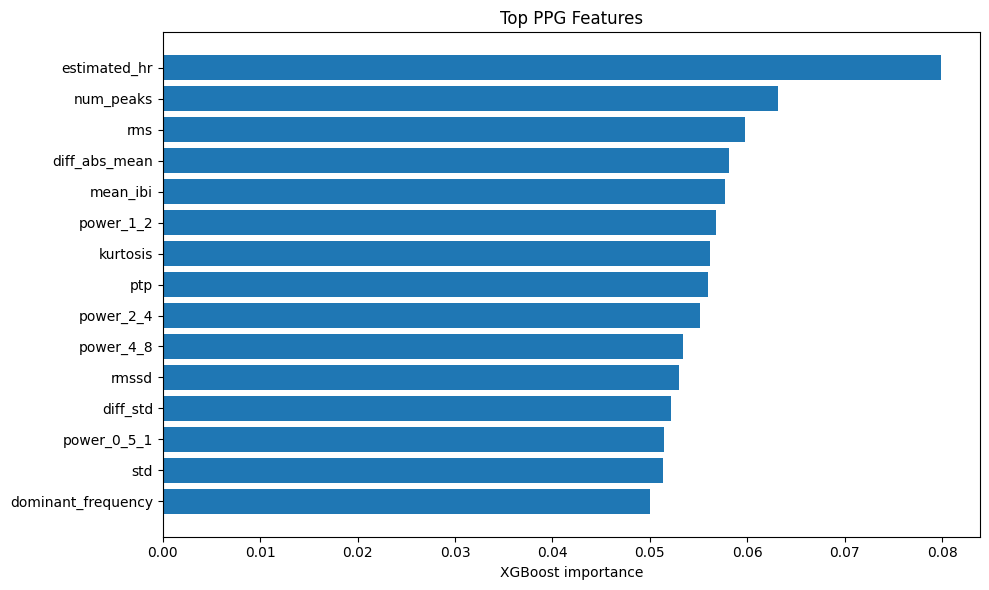

In [40]:
plt.figure(figsize=(10, 6))

top = importance_df.head(15)

plt.barh(
    top["feature"][::-1],
    top["importance"][::-1]
)

plt.xlabel("XGBoost importance")
plt.title("Top PPG Features")

plt.tight_layout()
plt.show()

In [41]:
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    accuracy_score,
    precision_recall_fscore_support
)
from xgboost import XGBClassifier

subjects = sorted(df["subject"].unique())

loso_results = []

for test_subject in subjects:

    print("\n" + "=" * 60)
    print("TEST SUBJECT:", test_subject)
    print("=" * 60)

    # Subject-independent split

    train_fold = df[
        df["subject"] != test_subject
    ].copy()

    test_fold = df[
        df["subject"] == test_subject
    ].copy()

    X_train = train_fold[feature_columns]
    y_train = train_fold["label"]

    X_test = test_fold[feature_columns]
    y_test = test_fold["label"]

    # Safety check
    assert set(train_fold["subject"]).isdisjoint(
        set(test_fold["subject"])
    )

    # Missing-value imputation
    # TRAIN ONLY

    imputer = SimpleImputer(
        strategy="median"
    )

    X_train_clean = imputer.fit_transform(X_train)
    X_test_clean = imputer.transform(X_test)

    # Class balancing

    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train
    )

    # Fresh model for this fold

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=3,

        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,

        subsample=0.8,
        colsample_bytree=0.8,

        reg_lambda=1.0,

        eval_metric="mlogloss",

        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_clean,
        y_train,
        sample_weight=sample_weights
    )

    # Evaluation

    y_pred = model.predict(X_test_clean)

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision, recall, f1, support = (
        precision_recall_fscore_support(
            y_test,
            y_pred,
            labels=[0, 1, 2],
            zero_division=0
        )
    )

    loso_results.append({
        "subject": test_subject,

        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "macro_f1": macro_f1,

        "hypo_precision": precision[0],
        "hypo_recall": recall[0],
        "hypo_f1": f1[0],
        "hypo_n": support[0],

        "normal_precision": precision[1],
        "normal_recall": recall[1],
        "normal_f1": f1[1],
        "normal_n": support[1],

        "hyper_precision": precision[2],
        "hyper_recall": recall[2],
        "hyper_f1": f1[2],
        "hyper_n": support[2]
    })

    print(
        f"Macro F1: {macro_f1:.3f} | "
        f"Balanced Acc: {balanced_acc:.3f}"
    )


TEST SUBJECT: c1s01
Macro F1: 0.295 | Balanced Acc: 0.321

TEST SUBJECT: c1s02
Macro F1: 0.344 | Balanced Acc: 0.334

TEST SUBJECT: c1s03
Macro F1: 0.322 | Balanced Acc: 0.325

TEST SUBJECT: c1s04
Macro F1: 0.315 | Balanced Acc: 0.412

TEST SUBJECT: c1s05
Macro F1: 0.163 | Balanced Acc: 0.282

TEST SUBJECT: c2s01
Macro F1: 0.310 | Balanced Acc: 0.340

TEST SUBJECT: c2s02
Macro F1: 0.268 | Balanced Acc: 0.263

TEST SUBJECT: c2s03
Macro F1: 0.325 | Balanced Acc: 0.327

TEST SUBJECT: c2s04
Macro F1: 0.256 | Balanced Acc: 0.322

TEST SUBJECT: c2s05
Macro F1: 0.296 | Balanced Acc: 0.356


In [42]:
loso_df = pd.DataFrame(loso_results)

display(
    loso_df[
        [
            "subject",
            "macro_f1",
            "balanced_accuracy",
            "hypo_recall",
            "normal_recall",
            "hyper_recall"
        ]
    ].round(3)
)

,subject,macro_f1,balanced_accuracy,hypo_recall,normal_recall,hyper_recall
0,c1s01,0.295,0.321,0.122,0.602,0.239
1,c1s02,0.344,0.334,0.000,0.811,0.192
2,c1s03,0.322,0.325,0.058,0.629,0.289
3,c1s04,0.315,0.412,0.333,0.676,0.225
4,c1s05,0.163,0.282,0.019,0.306,0.522
5,c2s01,0.310,0.340,0.046,0.571,0.403
6,c2s02,0.268,0.263,0.111,0.575,0.102
7,c2s03,0.325,0.327,0.047,0.860,0.073
8,c2s04,0.256,0.322,0.106,0.378,0.481
9,c2s05,0.296,0.356,0.015,0.692,0.363


print("XGBOOST PPG BASELINE")
print("---------------------")

print(
    "Mean Macro F1:",
    round(loso_df["macro_f1"].mean(), 3)
)

print(
    "Std Macro F1:",
    round(loso_df["macro_f1"].std(), 3)
)

print(
    "Mean Balanced Accuracy:",
    round(
        loso_df["balanced_accuracy"].mean(),
        3
    )
)

print(
    "Mean Hypoglycemia Recall:",
    round(
        loso_df["hypo_recall"].mean(),
        3
    )
)

print(
    "Mean Hyperglycemia Recall:",
    round(
        loso_df["hyper_recall"].mean(),
        3
    )
)

In [44]:
RESULT_DIR = PROJECT / "results"
RESULT_DIR.mkdir(exist_ok=True)

loso_df.to_csv(
    RESULT_DIR / "xgboost_ppg_loso.csv",
    index=False
)

print("Saved.")

Saved.


In [47]:
from sklearn.dummy import DummyClassifier

dummy_results = []

for test_subject in subjects:

    train_fold = df[
        df["subject"] != test_subject
    ]

    test_fold = df[
        df["subject"] == test_subject
    ]

    X_train = train_fold[feature_columns]
    y_train = train_fold["label"]

    X_test = test_fold[feature_columns]
    y_test = test_fold["label"]

    dummy = DummyClassifier(
        strategy="most_frequent"
    )

    dummy.fit(X_train, y_train)

    y_pred = dummy.predict(X_test)

    dummy_results.append({
        "subject": test_subject,

        "macro_f1": f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_test,
                y_pred
            )
    })

dummy_df = pd.DataFrame(dummy_results)

print("DUMMY MODEL")
print(
    "Mean Macro F1:",
    round(dummy_df["macro_f1"].mean(), 3)
)

print(
    "Mean Balanced Accuracy:",
    round(
        dummy_df["balanced_accuracy"].mean(),
        3
    )
)

DUMMY MODEL
Mean Macro F1: 0.303
Mean Balanced Accuracy: 0.333
